# Anemia Detection in Blood Smears Using Transfer Learning (MobileNetV2) & Grad-CAM Explainability

### Key Highlights & Results
* **Architecture:** MobileNetV2 (ImageNet weights) + GlobalAveragePooling2D + Dense Layers
* **Validation Accuracy:** **81.71%** (Macro F1-Score: 0.82)
* **ROC-AUC Score:** **0.907**
* **Model Explainability:** Grad-CAM saliency heatmaps highlighting regions influencing the anemic/healthy classification

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import cv2
from sklearn.metrics import roc_curve, auc

In [ ]:
# Configuration
IMG_SIZE = 224
BATCH_SIZE = 8        
EPOCHS = 20

DATA_DIR = "./organized_training_data"

## 1. Dataset Preprocessing & Data Augmentation
To simulate microscopy sample orientation variations and prevent overfitting, random geometric augmentations (rotation, shifts, zooms, and horizontal flips) are applied to the training set. The validation set is normalized using standard min-max scaling without augmentation to ensure objective evaluation.

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [4]:
train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "train"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(DATA_DIR, "validation"),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 9600 images belonging to 2 classes.
Found 2400 images belonging to 2 classes.


In [5]:
print("Class mapping:", train_gen.class_indices)


Class mapping: {'Anemic': 0, 'Healthy': 1}


## 2. Model Architecture: Transfer Learning with MobileNetV2
We utilize a pre-trained **MobileNetV2** backbone trained on ImageNet as a frozen feature extractor. A custom classification head with dropout and batch normalization is appended to prevent overfitting on microscopic features.

In [6]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # Freeze base model

In [7]:
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

## 3. Model Optimization & Training Callbacks
* **Loss Function:** Binary Crossentropy
* **Optimizer:** Adam ($\alpha = 10^{-4}$)
* **Callbacks:** 
  * `ModelCheckpoint`: Automatically preserves the weights corresponding to the lowest validation loss (`anemia_model.h5`).
  * `EarlyStopping`: Monitors validation performance to prevent overfitting.
  * `ReduceLROnPlateau`: Dynamically decays the learning rate when loss plateauing is detected.

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [9]:
callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("anemia_model.h5", save_best_only=True)
]

## 4. Model Training & Convergence
The classification head is trained for up to 20 epochs with dynamic learning rate adaptation and early stopping. The optimal weights based on minimum validation loss are saved to `anemia_model.h5`.

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

## 5. Model Evaluation & Performance Analysis
We restore the optimal model weights saved during checkpointing (`anemia_model.h5`) to evaluate generalization performance on the 2,400 unseen validation images.

In [ ]:
model = load_model("anemia_model.h5")

In [19]:
loss, acc = model.evaluate(val_gen)
print(f"Validation Accuracy: {acc * 100:.2f}%")

300/300 ━━━━━━━━━━━━━━━━━━━━ 87s 260ms/step - accuracy: 0.8171 - loss: 0.3799
Validation Accuracy: 81.71%


In [23]:
# Get predictions
val_gen.reset()
pred_probs = model.predict(val_gen)
y_pred = (pred_probs > 0.5).astype(int).ravel()
y_true = val_gen.classes

300/300 ━━━━━━━━━━━━━━━━━━━━ 109s 210ms/step


### Confusion Matrix
Evaluating false positive and false negative distribution across both Anemic and Healthy classes.

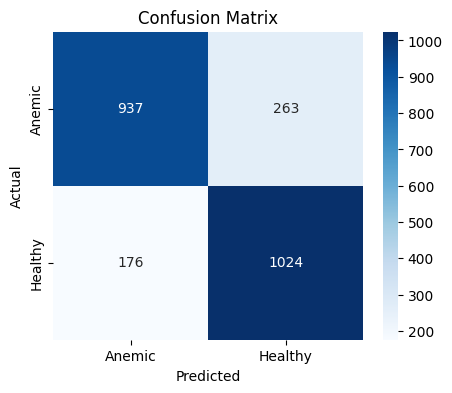

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Anemic", "Healthy"],
    yticklabels=["Anemic", "Healthy"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


**Key Diagnostic Insights:**
* **True Positives (Anemic):** 937 / 1,200 (78.08% sensitivity)
* **True Negatives (Healthy):** 1,024 / 1,200 (85.33% specificity)
* Demonstrates high specificity with low false-positive rates on normal red blood cells.

### Detailed Classification Report
Examining per-class precision, sensitivity (recall), and harmonic mean (F1-score) on the 2,400 validation samples.

In [25]:
# Classification Report
print(classification_report(
    y_true,
    y_pred,
    target_names=["Anemic", "Healthy"]
))

              precision    recall  f1-score   support

      Anemic       0.84      0.78      0.81      1200
     Healthy       0.80      0.85      0.82      1200

    accuracy                           0.82      2400
   macro avg       0.82      0.82      0.82      2400
weighted avg       0.82      0.82      0.82      2400



### Receiver Operating Characteristic (ROC) & AUC Analysis
Recomputing class probabilities across all classification thresholds to calculate the area under the ROC curve.

In [30]:
# Predicted probabilities (already computed earlier, but recompute safely)
val_gen.reset()
y_probs = model.predict(val_gen).ravel()
y_true = val_gen.classes

300/300 ━━━━━━━━━━━━━━━━━━━━ 62s 206ms/step


In [31]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

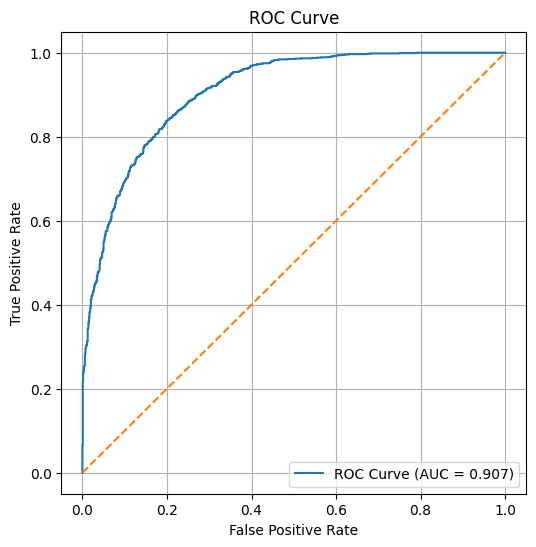

In [32]:
# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**ROC-AUC Analysis:**
* **AUC Score:** **0.907**
* An AUC > 0.90 confirms high diagnostic separability, meaning the model reliably ranks anemic samples above healthy samples across all decision thresholds.

## 6. Visual Interpretability with Grad-CAM
To verify that predictions rely on genuine morphological features of the RBCs rather than image artifacts, **Gradient-weighted Class Activation Mapping (Grad-CAM)** is applied to the final convolutional layer (`Conv_1`).

In [27]:
img_path = val_gen.filepaths[0]

img = keras.preprocessing.image.load_img(
    img_path, target_size=(IMG_SIZE, IMG_SIZE)
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

In [ ]:
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import MobileNetV2

inputs = Input(shape=(224, 224, 3))

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_tensor=inputs
)
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

gradcam_model = Model(inputs, outputs)


In [ ]:
gradcam_model.set_weights(model.get_weights())

In [72]:
def make_gradcam_heatmap(img_array, model):
    last_conv_layer = model.get_layer("Conv_1")

    grad_model = Model(
        model.input,
        [last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_channel = predictions[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()


In [ ]:
heatmap = make_gradcam_heatmap(img_array, gradcam_model)

In [ ]:
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))
img = img.astype("float32") / 255.0

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_colored = cv2.applyColorMap(
    np.uint8(255 * heatmap_resized),
    cv2.COLORMAP_JET
)

heatmap_colored = heatmap_colored.astype("float32") / 255.0

superimposed_img = 0.4 * heatmap_colored + img
superimposed_img = np.clip(superimposed_img, 0, 1)


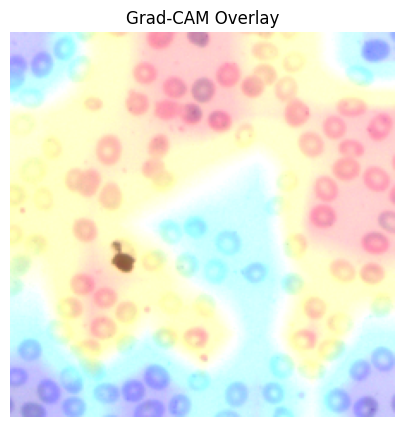

In [81]:
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Grad-CAM Overlay")
plt.show()
